# Implementations of Linear Regression

## 1.1 Implementing Linear Regression from Scratch
Data pipeline, model (deep neural network), loss function, mini-batch, optimisation (gradient descent)

In [1]:
%matplotlib inline
import random
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils import data
# from d2l import torch as d2l 

In [2]:
def synthetic_data(w, b, num_examples):  
    """ add noise """
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

Constructing an artificial dataset based on a noisy linear model. We generate the dataset and its labels using W=[2,−3.4]^⊤, b=4.2, and the noise term \epsilon:

In [3]:
def synthetic_data(w, b, num_examples):  
    """ generate y = Xw + b + noise """
    X = torch.normal(0, 1, (num_examples, len(w)))
    """ Randomly create tensors using normal distribution with mu = 0, std = 1 """
    y = torch.matmul(X, w) + b
    """ Compute the values of linear function """
    y += torch.normal(0, 0.01, y.shape)
    """ Randomly create noise """
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

Each row in features contains a 2d data sample, and each row in labels contains a 1d label value (a scalar).

In [6]:
print('features:', features.shape, '\nlabel:', labels.shape)

features: torch.Size([1000, 2]) 
label: torch.Size([1000, 1])


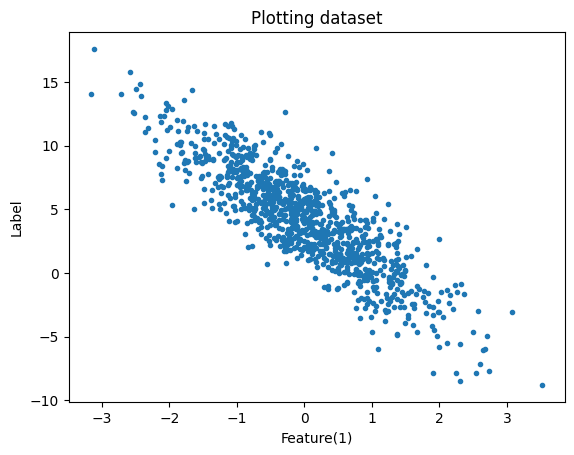

In [12]:
# Prepare data
f = np.array(features[:, (1)].detach().numpy())
l = np.array(labels.detach().numpy())

# Plot the data
plt.plot(f, l, marker=".", linewidth=0)

# Add labels and a title
plt.xlabel("Feature(1)")
plt.ylabel("Label")
plt.title("Plotting dataset")

# Display the plot
plt.show()

Define a function `data_iter` that takes the batch size, feature matrix, and label vector as input and generates a mini-batch of size `batch_size`.

In [29]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    """ Create an index for each sample from 0, 1, ..."""
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.6903, -2.0043],
        [-1.1471,  1.5341],
        [ 1.0023,  0.8242],
        [-1.8576, -0.5101],
        [-0.2977,  1.9732],
        [-0.5760,  1.0536],
        [-0.0369, -0.8245],
        [-0.0668,  1.7516],
        [-1.0588,  0.8117],
        [ 2.1314, -0.1092]]) 
 tensor([[ 9.6139],
        [-3.3080],
        [ 3.3965],
        [ 2.2168],
        [-3.0922],
        [-0.5203],
        [ 6.9208],
        [-1.9052],
        [-0.6595],
        [ 8.8251]])


Define and initialize model parameters

In [7]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

Define the model:

In [8]:
def linreg(X, w, b):  
    """ Linear regression model """
    return torch.matmul(X, w) + b

Define loss function:

In [9]:
def squared_loss(y_hat, y):  
    """ Mean squared loss """
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

Optimiser: Statistical Gradient Decent

In [10]:
def sgd(params, lr, batch_size):  
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

Training

In [11]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.035833
epoch 2, loss 0.000128
epoch 3, loss 0.000051


## 1.2 Concise implementation of Linear Regression

Call the existing API in PyTorch to read data

Data Loader: Use torch.utils.data.DataLoader to handle batching.

In [12]:
def load_array(data_arrays, batch_size, is_train=True):  
    """Construct a Pytorch data iterater"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

next(iter(data_iter))


[tensor([[-1.6844, -0.1003],
         [ 2.2057,  0.9801],
         [-0.4286, -0.6707],
         [-0.4641, -0.5159],
         [-0.0676, -0.7699],
         [-1.0859,  0.9926],
         [ 1.2949, -0.6497],
         [-0.5480,  0.4521],
         [ 1.4810,  2.3128],
         [ 2.1361, -0.4506]]),
 tensor([[ 1.1854],
         [ 5.2791],
         [ 5.6101],
         [ 5.0232],
         [ 6.6750],
         [-1.3596],
         [ 8.9712],
         [ 1.5691],
         [-0.6962],
         [10.0013]])]

Use predefined layers in Pytorch:

Model: Use torch.nn.Linear(m, n).

In [13]:
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

Initialisation of parameters:

In [14]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

The mean squared error (or L_2 error) is calculated using torch.nn.MSELoss()

In [15]:
loss = nn.MSELoss()

Optimizer: Use torch.optim.SGD(model.parameters(), lr=0.03)

Instantiate an SGD instance (SGD=Statistical Gradient Decent) to update parameters:

In [16]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

The training process code is very similar to what we did when we implemented it from scratch:

In [17]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000211
epoch 2, loss 0.000102
epoch 3, loss 0.000103


Compare the true parameters of the generated dataset with the model parameters obtained by training with limited data.

In [18]:
w = net[0].weight.data
print('Estimated error of w: ', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('Estimated error of b: ', true_b - b)

Estimated error of w:  tensor([0.0001, 0.0003])
Estimated error of b:  tensor([-0.0006])
